<!-- CURRICULUM_HEADER_START -->
<div class="mh"><p class="mh-crumb"><a href="/series/forecasting/index.html">Forecasting with Machine Learning</a><span class="sep">·</span>Part 4 · Explaining forecasts</p><p class="mh-facts"><span class="lvl lvl-intermediate">Intermediate</span></p><p class="mh-assumes">Assumes <a href="/blogs/forecast/2_ensemble_models.html">Ensemble models</a>.</p></div>
<!-- CURRICULUM_HEADER_END -->

::: {.callout-note appearance="simple" icon=false}
## TL;DR

A forecast you cannot decompose is hard to defend to the people who act on it. SHAP (SHapley Additive exPlanations) splits each prediction into a baseline plus one additive contribution per feature, and `TreeExplainer` computes those contributions exactly for gradient boosting. Applied to the berry-weight model, this module leaves you able to read a beeswarm plot for what drives the model overall and a waterfall plot for why one record got the value it did.
:::

> **Prerequisite**: see [Feature engineering](../1_feature_engineering/) and [Ensemble models](../2_ensemble_models/) for context.

In [1]:
# ── Setup: data + feature engineering + model training ───────────────────────
# (See Tutorial 1 & 2 for explanations of these steps)
import pandas as pd
import numpy as np
from datetime import date, timedelta
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer
from sklearn.ensemble import GradientBoostingRegressor
from feature_engine.creation import CyclicalFeatures
from feature_engine.encoding import OrdinalEncoder
from feature_engine.timeseries.forecasting import LagFeatures, WindowFeatures
import matplotlib.pyplot as plt
import shap
import warnings

warnings.filterwarnings("ignore")

np.random.seed(42)
WEATHER_COLS = [
    "temp_mean_c",
    "rainfall_mm",
    "solar_rad_wm2",
    "humidity_pct",
    "wind_speed_ms",
]
FIELDS = ["F01", "F02", "F03", "F04", "F05"]
VARIETIES = {
    "F01": "Chardonnay",
    "F02": "Chardonnay",
    "F03": "Pinot Noir",
    "F04": "Merlot",
    "F05": "Merlot",
}
PREDICTORS = [
    "week_of_year_sin",
    "week_of_year_cos",
    "weeks_since_pruning_sin",
    "weeks_since_pruning_cos",
    "weeks_since_pruning",
    "variety",
    "field_id",
    *WEATHER_COLS,
    "temp_mean_c_lag_1",
    "temp_mean_c_lag_2",
    "temp_mean_c_lag_3",
    "rainfall_mm_lag_1",
    "rainfall_mm_lag_2",
    "rainfall_mm_lag_3",
    "solar_rad_wm2_lag_1",
    "solar_rad_wm2_lag_2",
    "solar_rad_wm2_lag_3",
    "humidity_pct_lag_1",
    "humidity_pct_lag_2",
    "humidity_pct_lag_3",
    "wind_speed_ms_lag_1",
    "temp_mean_c_window_4_mean",
    "rainfall_mm_window_4_mean",
    "solar_rad_wm2_window_4_mean",
    "berry_weight_g_lag_52",
    "berry_weight_g_lag_1",
    "log_weight_lag52",
]
today = date(2026, 3, 14)
last_saturday = today - timedelta(days=(today.weekday() + 2) % 7)
start_date = last_saturday - timedelta(weeks=3 * 52 - 1)
weekly_dates = [start_date + timedelta(weeks=i) for i in range(3 * 52)]


def pruning_week(d):
    woy = (d - date(d.year, 1, 1)).days // 7
    return woy - 8 if woy >= 8 else woy + 52 - 8


def biological_weight_curve(wsp, variety):
    base = {"Chardonnay": 1.8, "Pinot Noir": 1.4, "Merlot": 2.2}[variety]
    w = wsp % 52
    return max(
        0.1,
        base * (1 / (1 + np.exp(-0.3 * (w - 14)))) * (1 - 0.3 * max(0, w - 22) / 30),
    )


records = []
for field in FIELDS:
    variety = VARIETIES[field]
    fe = np.random.normal(0, 0.1)
    for d in weekly_dates:
        wsp = pruning_week(d)
        woy = (d - date(d.year, 1, 1)).days // 7
        base_w = biological_weight_curve(wsp, variety)
        tm = 15 + 10 * np.sin(2 * np.pi * woy / 52) + np.random.normal(0, 2)
        rf = max(0, np.random.exponential(8) * (1 - 0.5 * np.sin(2 * np.pi * woy / 52)))
        sr = 180 + 120 * np.sin(2 * np.pi * (woy - 13) / 52) + np.random.normal(0, 20)
        hm = 60 + 15 * np.cos(2 * np.pi * woy / 52) + np.random.normal(0, 5)
        ws = max(0, np.random.exponential(3))
        we = (
            0.04 * (tm - 15)
            - 0.005 * rf
            + 0.001 * sr
            - 0.002 * hm
            + np.random.normal(0, 0.08)
        )
        records.append(
            {
                "date": d,
                "field_id": field,
                "variety": variety,
                "berry_weight_g": round(max(0.05, base_w + fe + we), 3),
                "week_of_year": woy,
                "weeks_since_pruning": wsp,
                "temp_mean_c": round(tm, 1),
                "rainfall_mm": round(max(0, rf), 1),
                "solar_rad_wm2": round(sr, 1),
                "humidity_pct": round(float(np.clip(hm, 20, 100)), 1),
                "wind_speed_ms": round(ws, 2),
            }
        )
df = pd.DataFrame(records).sort_values(["field_id", "date"]).reset_index(drop=True)

global_fe = Pipeline(
    [
        (
            "cyclical",
            CyclicalFeatures(
                variables=["week_of_year", "weeks_since_pruning"], drop_original=False
            ),
        ),
        (
            "encoding",
            OrdinalEncoder(
                encoding_method="arbitrary", variables=["variety", "field_id"]
            ),
        ),
    ]
)


def _fill_weekly_gaps(X):
    pieces = []
    for field, grp in X.groupby("field_id"):
        grp = grp.set_index("date").sort_index()
        full_idx = pd.date_range(grp.index.min(), grp.index.max(), freq="W-SAT")
        grp = grp.reindex(full_idx)
        grp["date"] = full_idx.date
        grp["field_id"] = field
        grp["_is_gap"] = grp["berry_weight_g"].isna()
        pieces.append(grp.reset_index(drop=True))
    return pd.concat(pieces).sort_values(["field_id", "date"]).reset_index(drop=True)


def _apply_grouped_ts_features(X):
    wl = LagFeatures(variables=WEATHER_COLS, periods=[1, 2, 3], sort_index=False)
    tl = LagFeatures(variables=["berry_weight_g"], periods=[1, 52], sort_index=False)
    ww = WindowFeatures(
        variables=WEATHER_COLS, functions=["mean"], window=4, sort_index=False
    )
    groups = []
    for _, grp in X.groupby("field_id"):
        g = grp.copy()
        g = wl.fit_transform(g)
        g = tl.fit_transform(g)
        g = ww.fit_transform(g)
        groups.append(g)
    result = pd.concat(groups).sort_index()
    return result[~result["_is_gap"]].drop(columns="_is_gap").reset_index(drop=True)


def _add_log_lag52(X):
    X = X.copy()
    X["log_weight_lag52"] = np.log(X["berry_weight_g_lag_52"].clip(lower=0.01))
    return X


grouped_fe = Pipeline(
    [
        ("gap_check", FunctionTransformer(_fill_weekly_gaps)),
        ("ts_features", FunctionTransformer(_apply_grouped_ts_features)),
        ("log_lag52", FunctionTransformer(_add_log_lag52)),
    ]
)
df_global = global_fe.fit_transform(df)
df_transformed = grouped_fe.fit_transform(df_global)
model_df = df_transformed.dropna(subset=PREDICTORS).copy()
cutoff = model_df["date"].max() - timedelta(weeks=8)
train = model_df[model_df["date"] <= cutoff]
test = model_df[model_df["date"] > cutoff]

# GBR trained on log(y) — cleaner for TreeExplainer than the VotingRegressor wrapper
gbr = GradientBoostingRegressor(
    n_estimators=200, learning_rate=0.05, max_depth=4, random_state=42
)
X_train = train[PREDICTORS]
X_test = test[PREDICTORS]
gbr.fit(X_train, np.log(train["berry_weight_g"]))
print("Setup complete. GBR trained on log-scale target.")

/Users/fkm/GitHub/blogsss/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Setup complete. GBR trained on log-scale target.


## What SHAP computes

SHAP values are the Shapley values of cooperative game theory applied to features: each feature is a player, and the prediction is the payout to share. For a prediction $\hat{y}$, SHAP decomposes it as:

$$\hat{y} = \phi_0 + \sum_{i=1}^{p} \phi_i$$

where $\phi_0$ is the model's baseline (average prediction) and each $\phi_i$ is the contribution of feature $i$ to *this specific prediction*.

`TreeExplainer` exploits the tree structure to compute exact SHAP values efficiently — no approximation needed for gradient boosting or random forests.

In [2]:
explainer = shap.TreeExplainer(gbr)
shap_values = explainer(X_test)  # returns a shap.Explanation object

print(f"SHAP values shape : {shap_values.values.shape}  (samples × features)")
print(
    f"Baseline (E[log y]): {shap_values.base_values[0]:.4f}  → exp = {np.exp(shap_values.base_values[0]):.3f} g"
)

SHAP values shape : (40, 31)  (samples × features)
Baseline (E[log y]): 0.0894  → exp = 1.093 g


## Global importance with the beeswarm plot

Each dot is one test observation. The x-axis is the SHAP value (contribution to `log(berry_weight_g)`). Colour encodes the raw feature value (red = high, blue = low). Features are ordered by mean absolute SHAP value — the most influential features are at the top.

> SHAP values are in log space because GBR was trained on `log(y)`. The direction and ranking are identical to what you would see in original units.

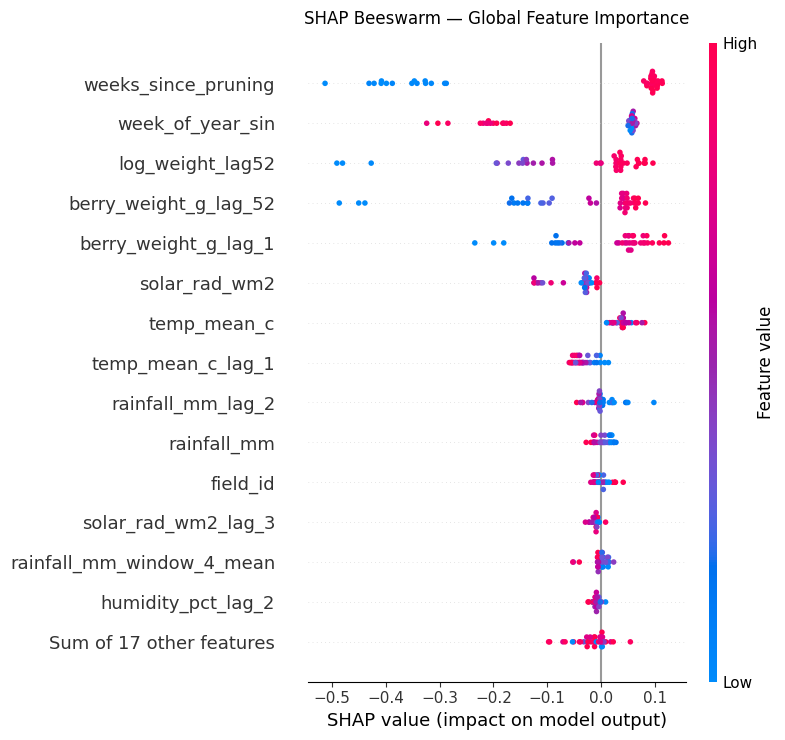

In [3]:
shap.plots.beeswarm(shap_values, max_display=15, show=False)
plt.title("SHAP Beeswarm — Global Feature Importance", pad=14)
plt.tight_layout()
plt.show()

## One prediction with the waterfall plot

The waterfall plot explains a **single prediction** from the baseline up to the final value. The baseline is the average log-prediction across the training set. Each bar shows exactly how much one feature pushes the prediction higher (red, positive SHAP) or lower (blue, negative SHAP); features not shown are collapsed into the `[X other features]` bar at the bottom.

We pick the test sample closest to the 90th percentile of predicted weight — a late-February Chardonnay observation from field F01 (variety code 0) — to show a clear pattern.

Sample index : 4
Field        : 0  (variety code 0)
Date         : 2026-02-21
Actual weight: 1.645 g
Predicted    : 1.561 g


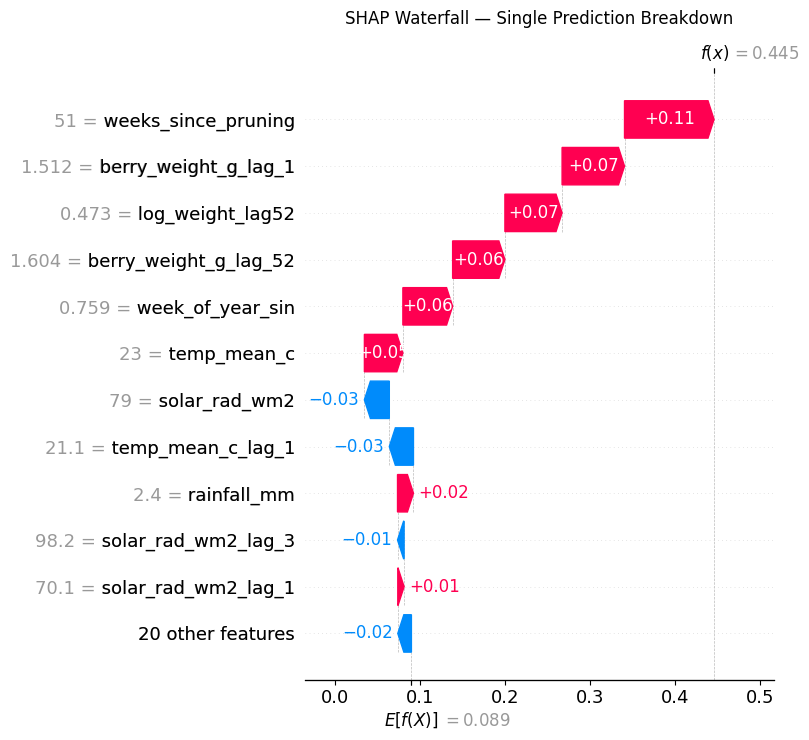

In [4]:
# Pick the test sample closest to the 90th percentile of predictions
preds_log = gbr.predict(X_test)
idx = int(np.argmin(np.abs(preds_log - np.percentile(preds_log, 90))))

print(f"Sample index : {idx}")
print(
    f"Field        : {test.iloc[idx]['field_id']}  (variety code {test.iloc[idx]['variety']})"
)
print(f"Date         : {test.iloc[idx]['date']}")
print(f"Actual weight: {test.iloc[idx]['berry_weight_g']:.3f} g")
print(f"Predicted    : {np.exp(preds_log[idx]):.3f} g")

shap.plots.waterfall(shap_values[idx], max_display=12, show=False)
plt.title("SHAP Waterfall — Single Prediction Breakdown", pad=14)
plt.tight_layout()
plt.show()

## Key takeaways

- `log_weight_lag52`, the same-week weight last year, is the dominant predictor: the biological growth cycle repeats annually.
- The `weeks_since_pruning` features rank next; growth stage drives expected weight more than any single weather variable.
- `berry_weight_g_lag_1` captures short-term momentum, and weather variables (temperature, solar radiation) contribute but rank below the phenological features.
- SHAP values here are in log space because the model was trained on `log(y)`; ranking and direction are unchanged in original units.
- Use the beeswarm to understand the model and the waterfall to defend one number.

| Plot | Scope | Use when... |
|------|-------|-------------|
| Beeswarm | Global (all test samples) | Understanding overall model behaviour |
| Waterfall | Local (one sample) | Debugging a single prediction or explaining to a stakeholder |

<!-- CURRICULUM_FOOTER_START -->
<div class="mf"><a class="mf-prev" href="/blogs/forecast/2_ensemble_models.html"><span>Previous</span>Ensemble models</a><a class="mf-up" href="/series/forecasting/index.html"><span>Series</span>Forecasting with Machine Learning</a><a class="mf-next" href="/blogs/darts-direct-vs-recursive.html"><span>Next</span>Direct vs recursive in Darts</a></div>
<!-- CURRICULUM_FOOTER_END -->